# Test Window Size

## Principal Settings

In [54]:
# Standard library imports
import sys
import numpy as np
import pandas as pd

# Project-specific imports
sys.path.append('../src/')
from models.types import ModelConfig
from models.har import HARModel

data_path = '../data/processed/HAR/'

## Functions

In [55]:
def sanity_check_coins(list_of_coins):
    """
    Check:
    - number of observations
    - date coverage
    - missing days
    - missing values
    - common overlapping period

    Returns
    -------
    tuple[pd.Timestamp, pd.Timestamp]
        (common_start, common_end) across all coins.
    """

    print("\n===== SANITY CHECK =====")

    coin_date_ranges = {}

    for coin in list_of_coins:

        df = pd.read_parquet(data_path + f'{coin}_har.parquet')
        df = df.sort_index()

        n_obs = len(df)
        start_date = df.index.min()
        end_date = df.index.max()

        # Check missing calendar days
        full_range = pd.date_range(start=start_date, end=end_date, freq="D")
        missing_days = len(full_range.difference(df.index))

        # Check missing values
        n_missing_values = df.isna().sum().sum()

        print(f"\nCoin: {coin}")
        print(f"Observations: {n_obs}")
        print(f"Period: {start_date.date()} → {end_date.date()}")
        print(f"Missing calendar days: {missing_days}")
        print(f"Missing values inside dataset: {n_missing_values}")

        coin_date_ranges[coin] = (start_date, end_date)

    # Overlapping period
    max_start = max([v[0] for v in coin_date_ranges.values()])
    min_end = min([v[1] for v in coin_date_ranges.values()])

    print("\n===== COMMON OVERLAP PERIOD =====")
    print(f"Common start: {max_start.date()}")
    print(f"Common end:   {min_end.date()}")

    if max_start >= min_end:
        raise ValueError("No common overlapping period across all coins.")

    print("===== END SANITY CHECK =====\n")

    return max_start, min_end


def run_test_window_size(
    list_of_coins,
    window_size_options=None,
    validation_window=50,
    train_ratio=0.8,
    loss_name="qlike"
):

    # -----------------------------
    # Sanity check first
    # -----------------------------
    common_start, common_end = sanity_check_coins(list_of_coins)

    if window_size_options is None:
        window_size_options = list(range(50, 1500, 50))

    detailed_results = []
    per_coin_summary = []
    global_summary = []

    for L in window_size_options:

        if L <= validation_window:
            continue

        all_window_train_losses = []
        all_window_val_losses = []
        n_coins_with_samples = 0

        print(f"\nTesting window size: {L}")

        for coin in list_of_coins:

            data_df = pd.read_parquet(data_path + f'{coin}_har.parquet')
            data_df = data_df.sort_index()
            data_df = data_df.loc[(data_df.index >= common_start) & (data_df.index <= common_end)]

            if data_df.empty:
                print(f"Skipping {coin}: no data in common overlap period.")
                continue

            X_full = data_df[["RV_d", "RV_w", "RV_m"]].values
            y_full = data_df["target"].values

            n_total = len(data_df)
            split_idx = int(n_total * train_ratio)

            X_train_full = X_full[:split_idx]
            y_train_full = y_full[:split_idx]
            dates_train = data_df.index[:split_idx]

            window_train_losses = []
            window_val_losses = []

            for end_idx in range(L, len(X_train_full) + 1):

                start_idx = end_idx - L

                X_window = X_train_full[start_idx:end_idx]
                y_window = y_train_full[start_idx:end_idx]

                X_subtrain = X_window[:-validation_window]
                y_subtrain = y_window[:-validation_window]

                X_val = X_window[-validation_window:]
                y_val = y_window[-validation_window:]

                if len(X_subtrain) <= 5:
                    continue

                config = ModelConfig(name=f"HAR_L{L}")
                model = HARModel(config)

                fit_result = model.fit(
                    X_subtrain,
                    y_subtrain,
                    X_val=X_val,
                    y_val=y_val,
                    loss_fn=getattr(model, loss_name)
                )

                window_train_losses.append(fit_result.train_loss)
                window_val_losses.append(fit_result.val_loss)

                detailed_results.append({
                    "coin": coin,
                    "window_size": L,
                    "window_end_date": dates_train[end_idx - 1],
                    "train_loss": fit_result.train_loss,
                    "val_loss": fit_result.val_loss
                })

            if len(window_val_losses) == 0:
                continue

            mean_val_coin = np.mean(window_val_losses)
            mean_train_coin = np.mean(window_train_losses)
            n_window_samples_coin = len(window_val_losses)

            all_window_train_losses.extend(window_train_losses)
            all_window_val_losses.extend(window_val_losses)
            n_coins_with_samples += 1

            per_coin_summary.append({
                "coin": coin,
                "window_size": L,
                "n_window_samples": n_window_samples_coin,
                "mean_train_loss": mean_train_coin,
                "mean_val_loss": mean_val_coin,
                "std_val_loss": np.std(window_val_losses)
            })

        if len(all_window_val_losses) > 0:

            global_summary.append({
                "window_size": L,
                "n_coins": n_coins_with_samples,
                "n_window_samples": len(all_window_val_losses),
                "mean_train_loss_global": np.mean(all_window_train_losses),
                "mean_val_loss_global": np.mean(all_window_val_losses),
                "std_val_loss_global": np.std(all_window_val_losses)
            })

    detailed_df = pd.DataFrame(detailed_results)
    per_coin_df = pd.DataFrame(per_coin_summary)
    global_df = pd.DataFrame(global_summary)

    return detailed_df, per_coin_df, global_df

## Runnings

In [56]:
result_path = "../results/test_window_size/"

all_list_of_coins = ["ADA", "BTC", "ETH", "SOL", "XRP"]

# Experiment by coin
for coin_name in all_list_of_coins:
    result_path_coin = result_path + f"{coin_name}/"
    list_of_coins = [coin_name]
    detailed_df, per_coin_df, global_df = run_test_window_size(
        list_of_coins=list_of_coins,
        validation_window=100,
        loss_name="qlike"
    )
    detailed_df.to_csv(result_path_coin + "detailed_results.csv", index=False)
    per_coin_df.to_csv(result_path_coin + "per_coin_summary.csv", index=False)
    # global_df is not relevant for single coin experiments
    
# Experiment integrated
detailed_df, per_coin_df, global_df = run_test_window_size(
    list_of_coins=all_list_of_coins,
    validation_window=100,
    loss_name="qlike"
)

result_path_integrated = result_path + "integrated/"
detailed_df.to_csv(result_path_integrated + "detailed_results.csv", index=False)
per_coin_df.to_csv(result_path_integrated + "per_coin_summary.csv", index=False)
global_df.to_csv(result_path_integrated + "global_summary.csv", index=False)


===== SANITY CHECK =====

Coin: ADA
Observations: 2787
Period: 2018-05-16 → 2025-12-31
Missing calendar days: 0
Missing values inside dataset: 0

===== COMMON OVERLAP PERIOD =====
Common start: 2018-05-16
Common end:   2025-12-31
===== END SANITY CHECK =====


Testing window size: 150

Testing window size: 200

Testing window size: 250

Testing window size: 300

Testing window size: 350

Testing window size: 400

Testing window size: 450

Testing window size: 500

Testing window size: 550

Testing window size: 600

Testing window size: 650

Testing window size: 700

Testing window size: 750

Testing window size: 800

Testing window size: 850

Testing window size: 900

Testing window size: 950

Testing window size: 1000

Testing window size: 1050

Testing window size: 1100

Testing window size: 1150

Testing window size: 1200

Testing window size: 1250

Testing window size: 1300

Testing window size: 1350

Testing window size: 1400

Testing window size: 1450

===== SANITY CHECK =====



## Inspect results

In [94]:
import pandas as pd
import os

results_path = "../results/test_window_size/"

### Integrated

In [95]:
integrated_results_path = results_path + "integrated/"
detailed_df = pd.read_csv(integrated_results_path + "detailed_results.csv")
per_coin_df = pd.read_csv(integrated_results_path + "per_coin_summary.csv")
global_df = pd.read_csv(integrated_results_path + "global_summary.csv")

In [96]:
display(global_df)

,window_size,n_coins,n_window_samples,mean_train_loss_global,mean_val_loss_global,std_val_loss_global
0,150,5,7015,8.188320e+06,1.187345e+08,4.169599e+08
1,200,5,6765,1.367649e+06,1.420408e+07,1.079817e+08
2,250,5,6515,8.319321e+05,4.451718e+06,4.856171e+07
3,300,5,6265,4.694607e+05,1.387585e+06,2.785083e+07
4,350,5,6015,4.485165e+05,4.592767e+05,1.620230e+07
5,400,5,5765,2.659542e+05,4.276946e+05,1.575121e+07
6,450,5,5515,1.362480e+05,3.651023e+05,1.231028e+07
7,500,5,5265,8.667687e+04,3.824386e+05,1.259889e+07
8,550,5,5015,1.822773e+03,3.872478e-01,2.012131e-01
9,600,5,4765,3.321528e-01,3.921166e-01,1.956719e-01


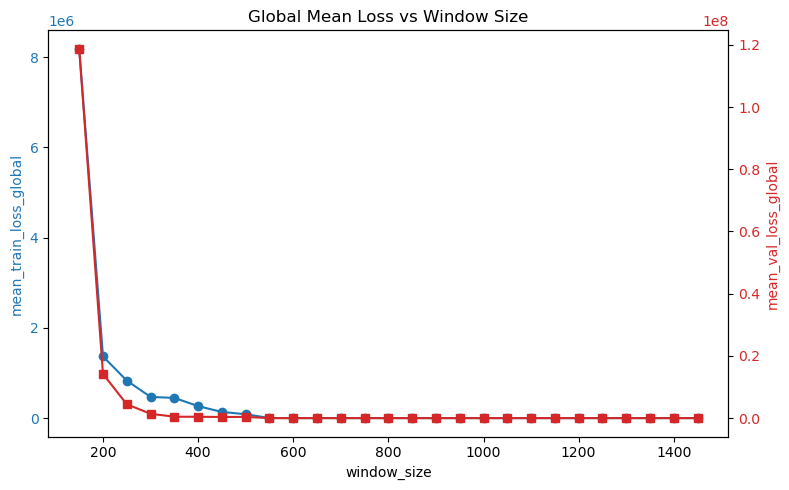

In [104]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(8, 5))

# Left y-axis: mean_train_loss_global
ax1.plot(
    global_df["window_size"],
    global_df["mean_train_loss_global"],
    marker="o",
    color="tab:blue",
    label="mean_train_loss_global"
)
ax1.set_xlabel("window_size")
ax1.set_ylabel("mean_train_loss_global", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

# Right y-axis: mean_val_loss_global
ax2 = ax1.twinx()
ax2.plot(
    global_df["window_size"],
    global_df["mean_val_loss_global"],
    marker="s",
    color="tab:red",
    label="mean_val_loss_global"
)
ax2.set_ylabel("mean_val_loss_global", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

plt.title("Global Mean Loss vs Window Size")
fig.tight_layout()
plt.show()

In [98]:
# Indices of minima
idx_train_min = global_df["mean_train_loss_global"].idxmin()
idx_val_min = global_df["mean_val_loss_global"].idxmin()

# Build 2-row summary dataframe
min_summary_df = (
    global_df.loc[[idx_train_min, idx_val_min], ["window_size", "mean_train_loss_global", "mean_val_loss_global"]]
    .rename(columns={"window_size": "L"})
    .reset_index(drop=True)
)

display(min_summary_df)

# Best L is the one with lowest mean of mean_train_loss_global and mean_val_loss_global
min_summary_df["loss_mean"] = (min_summary_df["mean_train_loss_global"] + min_summary_df["mean_val_loss_global"]) / 2
best_idx = min_summary_df["loss_mean"].idxmin()
print(f"Best window size L: {min_summary_df.loc[best_idx, 'L']} with loss mean: {min_summary_df.loc[best_idx, 'loss_mean']}")

min_summary_df["coin"] = "Integrated"
min_summary_df.rename(columns={
    "mean_train_loss_global": "mean_train_loss",
    "mean_val_loss_global": "mean_val_loss"
}, inplace=True)
summary_df = min_summary_df.loc[[best_idx]].reset_index(drop=True)

,L,mean_train_loss_global,mean_val_loss_global
0,650,0.330619,0.398384
1,1250,0.372367,0.352530


Best window size L: 1250 with loss mean: 0.3624487046049699


In [99]:
summary_df.to_latex()

'\\begin{tabular}{lrrrrl}\n\\toprule\n & L & mean_train_loss & mean_val_loss & loss_mean & coin \\\\\n\\midrule\n0 & 1250 & 0.372367 & 0.352530 & 0.362449 & Integrated \\\\\n\\bottomrule\n\\end{tabular}\n'

### Per Coin

In [100]:
import matplotlib.pyplot as plt

def plot_losses(per_coin_df):
    fig, ax1 = plt.subplots(figsize=(8, 5))

    # Left y-axis: mean_train_loss
    ax1.plot(
        per_coin_df["window_size"],
        per_coin_df["mean_train_loss"],
        marker="o",
        color="tab:blue",
        label="mean_train_loss"
    )
    ax1.set_xlabel("window_size")
    ax1.set_ylabel("mean_train_loss", color="tab:blue")
    ax1.tick_params(axis="y", labelcolor="tab:blue")

    # Right y-axis: mean_val_loss
    ax2 = ax1.twinx()
    ax2.plot(
        per_coin_df["window_size"],
        per_coin_df["mean_val_loss"],
        marker="s",
        color="tab:red",
        label="mean_val_loss"
    )
    ax2.set_ylabel("mean_val_loss", color="tab:red")
    ax2.tick_params(axis="y", labelcolor="tab:red")

    plt.title("Mean Loss vs Window Size")
    fig.tight_layout()
    plt.show()

    return fig, ax1, ax2

def build_min_summary_per_coin(per_coin_df):
    # Indices of minima
    idx_train_min = per_coin_df["mean_train_loss"].idxmin()
    idx_val_min = per_coin_df["mean_val_loss"].idxmin()

    # Build 2-row summary dataframe
    min_summary_df = (
        per_coin_df.loc[[idx_train_min, idx_val_min], ["window_size", "mean_train_loss", "mean_val_loss"]]
        .rename(columns={"window_size": "L"})
        .reset_index(drop=True)
    )

    return min_summary_df, idx_train_min, idx_val_min


=== BTC ===


,coin,window_size,n_window_samples,mean_train_loss,mean_val_loss,std_val_loss
0,BTC,150,2275,3.654607e+06,1.778135e+08,4.817848e+08
1,BTC,200,2225,6.200101e+05,4.253665e+07,1.762147e+08
2,BTC,250,2175,1.948398e+05,3.726366e+07,1.796711e+08
3,BTC,300,2125,1.694002e+05,9.908628e+06,8.224677e+07
4,BTC,350,2075,9.470770e+04,9.637644e+05,2.295667e+07
5,BTC,400,2025,2.870139e+04,7.091170e+05,1.983761e+07
6,BTC,450,1975,3.261824e+04,5.832393e+05,1.836933e+07
7,BTC,500,1925,3.140943e+04,5.983883e+05,1.860612e+07
8,BTC,550,1875,2.983100e+04,6.166886e+05,1.892926e+07
9,BTC,600,1825,2.946808e+04,4.013433e+05,1.451651e+07


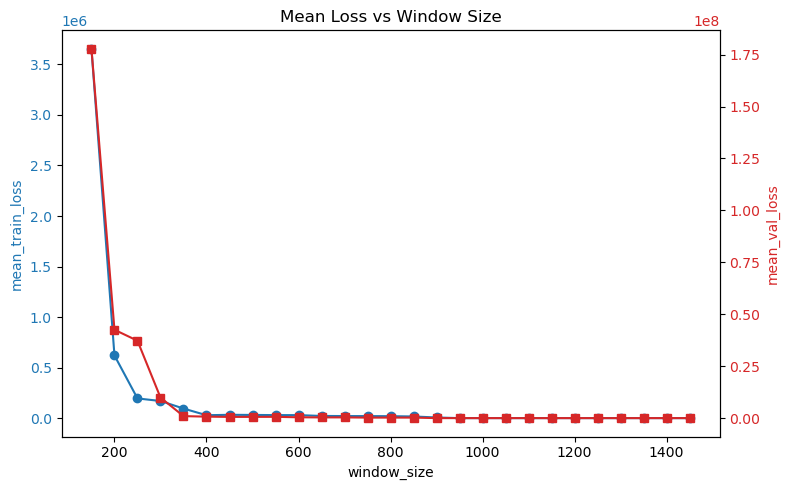

,L,mean_train_loss,mean_val_loss,loss_mean
0,1250,0.374455,0.396612,0.385533
1,1150,0.375448,0.383566,0.379507


Best window size L: 1150 with loss mean: 0.37950691773587886

=== ETH ===


,coin,window_size,n_window_samples,mean_train_loss,mean_val_loss,std_val_loss
0,ETH,150,2275,3.300277e+06,1.308687e+08,4.328188e+08
1,ETH,200,2225,1.154650e+06,2.433182e+07,1.201741e+08
2,ETH,250,2175,6.380506e+05,1.590390e+07,8.757944e+07
3,ETH,300,2125,2.361633e+05,2.285779e+06,2.398231e+07
4,ETH,350,2075,9.978650e+04,2.930831e+05,8.972702e+06
5,ETH,400,2025,6.935984e+04,2.493230e+05,8.793118e+06
6,ETH,450,1975,6.410705e+04,8.245078e+04,3.663250e+06
7,ETH,500,1925,6.201643e+04,7.636326e+04,3.349539e+06
8,ETH,550,1875,2.158456e+04,2.098814e+05,9.085694e+06
9,ETH,600,1825,2.469773e+04,2.045833e+05,8.737394e+06


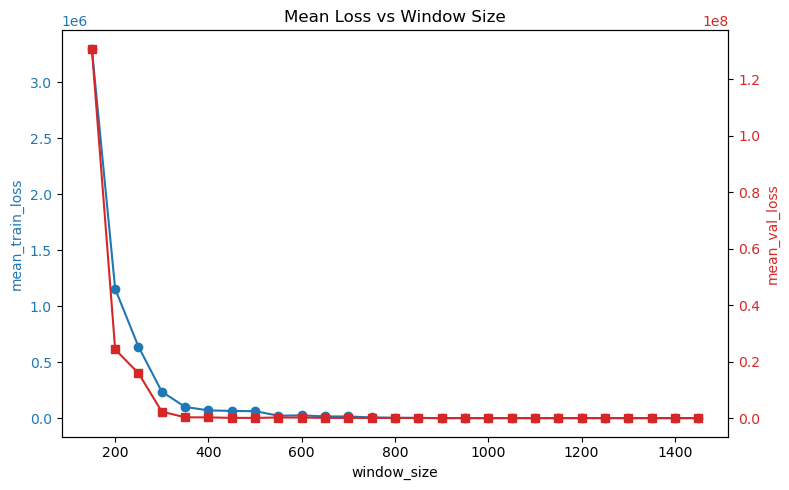

,L,mean_train_loss,mean_val_loss,loss_mean
0,900,0.320906,0.364735,0.34282
1,900,0.320906,0.364735,0.34282


Best window size L: 900 with loss mean: 0.342820128775969

=== ADA ===


,coin,window_size,n_window_samples,mean_train_loss,mean_val_loss,std_val_loss
0,ADA,150,2080,3.271405e+06,1.582567e+08,4.742531e+08
1,ADA,200,2030,1.121023e+06,4.939369e+07,1.888390e+08
2,ADA,250,1980,4.606567e+05,4.519950e+07,1.790816e+08
3,ADA,300,1930,2.128104e+05,1.946917e+07,1.383335e+08
4,ADA,350,1880,1.603613e+05,8.866602e+05,2.212244e+07
5,ADA,400,1830,1.448830e+05,7.120989e+05,2.181043e+07
6,ADA,450,1780,9.476289e+04,3.950032e+05,1.666051e+07
7,ADA,500,1730,9.274006e+04,4.064195e+05,1.689942e+07
8,ADA,550,1680,4.992452e+04,3.854273e+05,1.579310e+07
9,ADA,600,1630,3.938705e+04,3.972502e+05,1.603335e+07


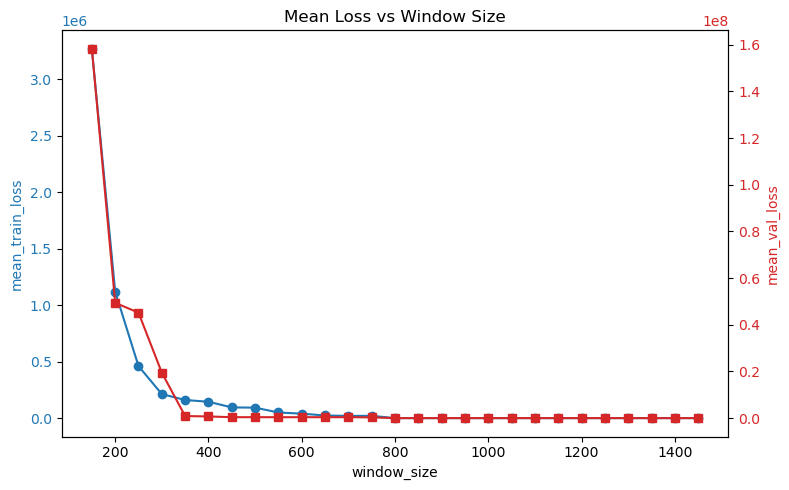

,L,mean_train_loss,mean_val_loss,loss_mean
0,800,0.323731,0.382044,0.352887
1,800,0.323731,0.382044,0.352887


Best window size L: 800 with loss mean: 0.35288747856729263

=== SOL ===


,coin,window_size,n_window_samples,mean_train_loss,mean_val_loss,std_val_loss
0,SOL,150,1403,1.156223e+07,1.930752e+08,5.733163e+08
1,SOL,200,1353,6.312856e+06,2.397028e+07,1.961018e+08
2,SOL,250,1303,4.159659e+06,9.886686e+06,9.363952e+07
3,SOL,300,1253,2.347302e+06,6.570816e+06,6.193672e+07
4,SOL,350,1203,2.242581e+06,2.228747e+06,3.615057e+07
5,SOL,400,1153,1.329770e+06,2.138471e+06,3.516881e+07
6,SOL,450,1103,6.812387e+05,1.825510e+06,2.747815e+07
7,SOL,500,1053,4.333829e+05,1.912191e+06,2.812001e+07
8,SOL,550,1003,9.112481e+03,3.195877e-01,1.202422e-01
9,SOL,600,953,2.876874e-01,3.171035e-01,1.220235e-01


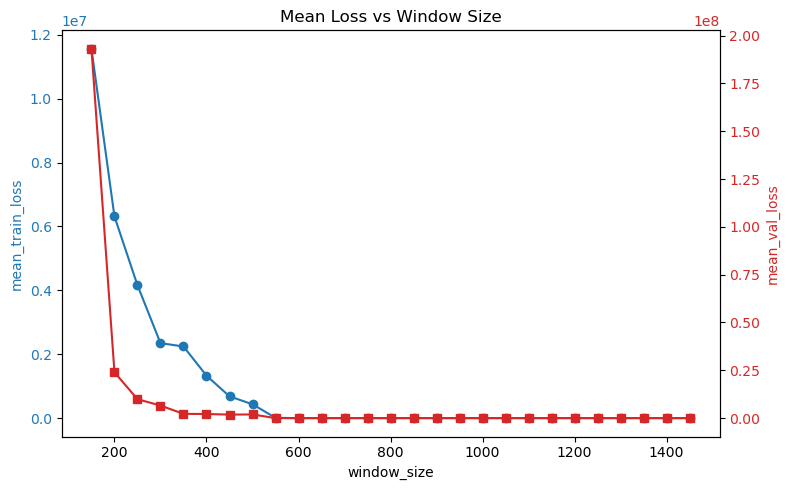

,L,mean_train_loss,mean_val_loss,loss_mean
0,1450,0.269357,0.296565,0.282961
1,1200,0.279160,0.260309,0.269735


Best window size L: 1200 with loss mean: 0.269734526724863

=== XRP ===


,coin,window_size,n_window_samples,mean_train_loss,mean_val_loss,std_val_loss
0,XRP,150,2067,1.524371e+07,1.859360e+08,5.423325e+08
1,XRP,200,2017,9.093410e+05,5.084434e+07,3.354793e+08
2,XRP,250,1967,2.924120e+05,3.324401e+07,2.419434e+08
3,XRP,300,1917,1.958031e+05,2.307839e+07,2.123419e+08
4,XRP,350,1867,1.771852e+05,5.452197e+05,7.274020e+06
5,XRP,400,1817,1.251755e+04,6.295429e+04,1.976394e+06
6,XRP,450,1767,4.286166e-01,2.293006e+04,9.635873e+05
7,XRP,500,1717,4.263794e-01,2.359778e+04,9.775087e+05
8,XRP,550,1667,4.263885e-01,4.939684e-01,2.205104e-01
9,XRP,600,1617,4.265679e-01,4.938257e-01,2.173715e-01


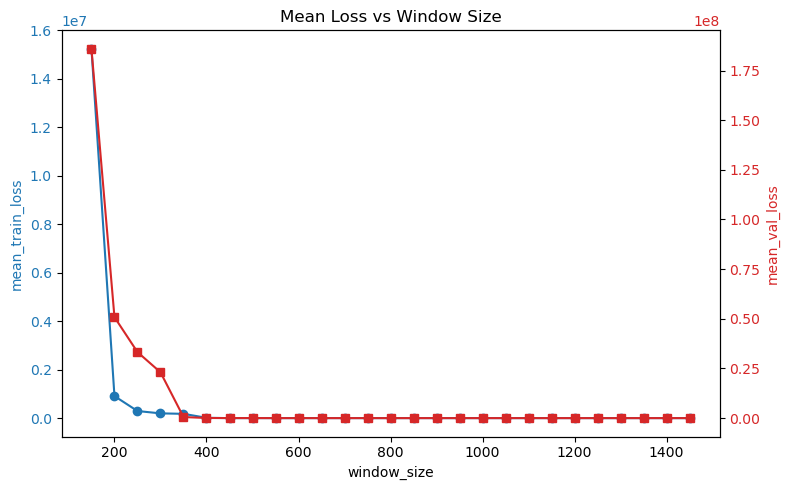

,L,mean_train_loss,mean_val_loss,loss_mean
0,500,0.426379,23597.778228,11799.102303
1,700,0.428394,0.490552,0.459473


Best window size L: 700 with loss mean: 0.45947285875267263


In [101]:
list_of_coins = ["BTC", "ETH", "ADA", "SOL", "XRP"]

for coin in list_of_coins:
    print(f"\n=== {coin} ===")
    coin_result_path = results_path + f"{coin}/"
    detailed_df = pd.read_csv(coin_result_path + "detailed_results.csv")
    per_coin_df = pd.read_csv(coin_result_path + "per_coin_summary.csv")
    display(per_coin_df)
    fig, ax1, ax2 = plot_losses(per_coin_df)
    min_summary_df, idx_train_min, idx_val_min = build_min_summary_per_coin(per_coin_df)
    min_summary_df["loss_mean"] = (min_summary_df["mean_train_loss"] + min_summary_df["mean_val_loss"]) / 2 
    display(min_summary_df)
    # Best L is the one with lowest mean of mean_train_loss and mean_val_loss
    best_idx = min_summary_df["loss_mean"].idxmin()
    print(f"Best window size L: {min_summary_df.loc[best_idx, 'L']} with loss mean: {min_summary_df.loc[best_idx, 'loss_mean']}")
    min_summary_df["coin"] = coin
    summary_df = pd.concat([summary_df, min_summary_df.loc[[best_idx]]], ignore_index=True)

### Length result

In [102]:
summary_df.set_index("coin", inplace=True)
display(summary_df)

summary_df.to_latex()

,L,mean_train_loss,mean_val_loss,loss_mean
coin,,,,
Integrated,1250,0.372367,0.352530,0.362449
BTC,1150,0.375448,0.383566,0.379507
ETH,900,0.320906,0.364735,0.342820
ADA,800,0.323731,0.382044,0.352887
SOL,1200,0.279160,0.260309,0.269735
XRP,700,0.428394,0.490552,0.459473


'\\begin{tabular}{lrrrr}\n\\toprule\n & L & mean_train_loss & mean_val_loss & loss_mean \\\\\ncoin &  &  &  &  \\\\\n\\midrule\nIntegrated & 1250 & 0.372367 & 0.352530 & 0.362449 \\\\\nBTC & 1150 & 0.375448 & 0.383566 & 0.379507 \\\\\nETH & 900 & 0.320906 & 0.364735 & 0.342820 \\\\\nADA & 800 & 0.323731 & 0.382044 & 0.352887 \\\\\nSOL & 1200 & 0.279160 & 0.260309 & 0.269735 \\\\\nXRP & 700 & 0.428394 & 0.490552 & 0.459473 \\\\\n\\bottomrule\n\\end{tabular}\n'